In the previous notebook models_manhattan.ipynb, we found that the Prophet and NeuralProphet models performed well in terms of forecasting rat sightings by day citywide. In this notebook, we will do some more feature engineering and hyperparameter tuning to obtain a better optimal model.

Because we wish this to be reusable, we will write things for Prophet and NeuralProphet separately. 

# Import Packages

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression

from pandas.tseries.holiday import USFederalHolidayCalendar
import itertools

import optuna
import logging

from statsforecast.adapters.prophet import AutoARIMAProphet

# Prophet

## Import the data

In [16]:
# set up the time series split
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

rs = pd.read_csv('../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-01 and after 2026-02-28.
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']

## Restrict to MANHATTAN

rs = rs[rs['borough']=='MANHATTAN']

## Drop the column with borough

rs = rs.drop(columns=['borough'])

## rename columns for prophet

rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)


## Prepare Prophet

In [17]:
date_range = pd.date_range(start="2020-01-01", end="2026-02-28")

# Generate US federal holidays
calendar = USFederalHolidayCalendar()
holidays = calendar.holidays(start=date_range.min(), end=date_range.max())

federal_holidays = pd.DataFrame({
    'holiday': 'federal_us',
    'ds': pd.to_datetime(holidays),
    'lower_window': 0,
    'upper_window': 1})

holidays = federal_holidays

In [18]:
## Add weather data.
import requests

lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()

if 'error' in data:
    nd = pd.read_csv("weatherdata.csv")
    nd = nd.set_index('date')
    wd = nd
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

wd

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,precipitation_sum,snowfall_sum
date,,,,,,,,,
2020-01-01,2020-01-01,4.4,-0.4,2.2,-0.3,-5.3,-3.4,0.0,0.00
2020-01-02,2020-01-02,8.7,-2.1,2.5,4.5,-6.6,-1.7,0.0,0.00
2020-01-03,2020-01-03,9.4,2.2,6.6,7.3,-1.1,4.1,4.3,0.00
2020-01-04,2020-01-04,9.6,5.8,7.7,7.9,1.0,5.7,6.0,0.00
2020-01-05,2020-01-05,5.1,-1.2,2.7,-1.0,-5.0,-3.5,0.8,0.00
...,...,...,...,...,...,...,...,...,...
2026-02-24,2026-02-24,-1.5,-11.8,-4.5,-5.9,-15.7,-9.3,0.0,0.00
2026-02-25,2026-02-25,2.5,-12.3,-1.1,-1.1,-16.4,-5.2,1.9,1.19
2026-02-26,2026-02-26,4.3,-3.6,1.2,1.3,-7.5,-2.4,1.2,0.28


In [ ]:
regressors = ['apparent_temperature_max', 'apparent_temperature_min', 'snowfall_sum']

wd = wd.reset_index(drop=True)  # remove index if needed
wd.rename(columns={'time': 'ds'}, inplace=True)  # 'time' column is the date
wd['ds'] = pd.to_datetime(wd['ds'])

rs['ds'] = pd.to_datetime(rs['ds'])

df = rs.merge(wd[['ds'] + regressors], on='ds', how='left')

In [22]:
rs_saved = rs.copy()

## Hyperparameter Tuning for AutoARIMAProphet

In [23]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

In [ ]:
### I need to fix this! For some reason, the Optuna values are not changing.

# tscv = TimeSeriesSplit(
#     n_splits=23,
#     test_size=14,
#     gap=0
#     )

# def objective(trial):
#     changepoint_prior_scale = trial.suggest_float("changepoint_prior_scale", 0.01, 2.0)
#     seasonality_prior_scale = trial.suggest_float("seasonality_prior_scale", 0.1, 10.0)
#     yearly_seasonality = trial.suggest_categorical("yearly_seasonality", [True])
#     weekly_seasonality = trial.suggest_categorical("weekly_seasonality", [True])
#     daily_seasonality = trial.suggest_categorical("daily_seasonality", [False])  

#     rmses = []

#     for train_idx, test_idx in tscv.split(df):
#         train_df = df.iloc[train_idx]
#         test_df = df.iloc[test_idx]
#         model = AutoARIMAProphet(
#             changepoint_prior_scale=changepoint_prior_scale,
#             seasonality_prior_scale=seasonality_prior_scale,
#             yearly_seasonality=yearly_seasonality,
#             weekly_seasonality=weekly_seasonality,
#             daily_seasonality=daily_seasonality,
#             holidays=holidays,
#         )
        
#         for reg in regressors:
#             model.add_regressor(reg)

#         model.fit(train_df)

#         forecast = model.predict(test_df)
#         print(forecast)
#         rmse = np.sqrt(np.mean((test_df['y'].values - forecast['yhat'].values) ** 2))        
#         rmses.append(rmse)

#     return np.mean(rmses)


# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=30)  # change n_trials as needed

# best_params = study.best_params
# print("Best hyperparameters:", best_params)
# print("Best RMSE:", study.best_value)

[I 2026-03-08 22:47:57,428] A new study created in memory with name: no-name-02175958-7b4e-45c7-8051-b6978162b698
[I 2026-03-08 22:49:09,052] Trial 0 finished with value: 4.929197835407765 and parameters: {'changepoint_prior_scale': 0.9448515258216375, 'seasonality_prior_scale': 0.4028453088601116, 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': False}. Best is trial 0 with value: 4.929197835407765.
[I 2026-03-08 22:50:16,273] Trial 1 finished with value: 4.929197835407765 and parameters: {'changepoint_prior_scale': 1.022846926504154, 'seasonality_prior_scale': 1.9911998672093243, 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_seasonality': False}. Best is trial 0 with value: 4.929197835407765.
[I 2026-03-08 22:51:24,978] Trial 2 finished with value: 4.929197835407765 and parameters: {'changepoint_prior_scale': 0.34794216227299046, 'seasonality_prior_scale': 6.703361007214147, 'yearly_seasonality': True, 'weekly_seasonality': True, 'daily_se

KeyboardInterrupt: 

## Train the Model

In [34]:
m = AutoARIMAProphet(holidays = holidays)
m.add_country_holidays(country_name='US')
m.fit(df)
future = m.make_future_dataframe(periods=14)
forecast = m.predict(future)

## Plots and Evaluation of the Model

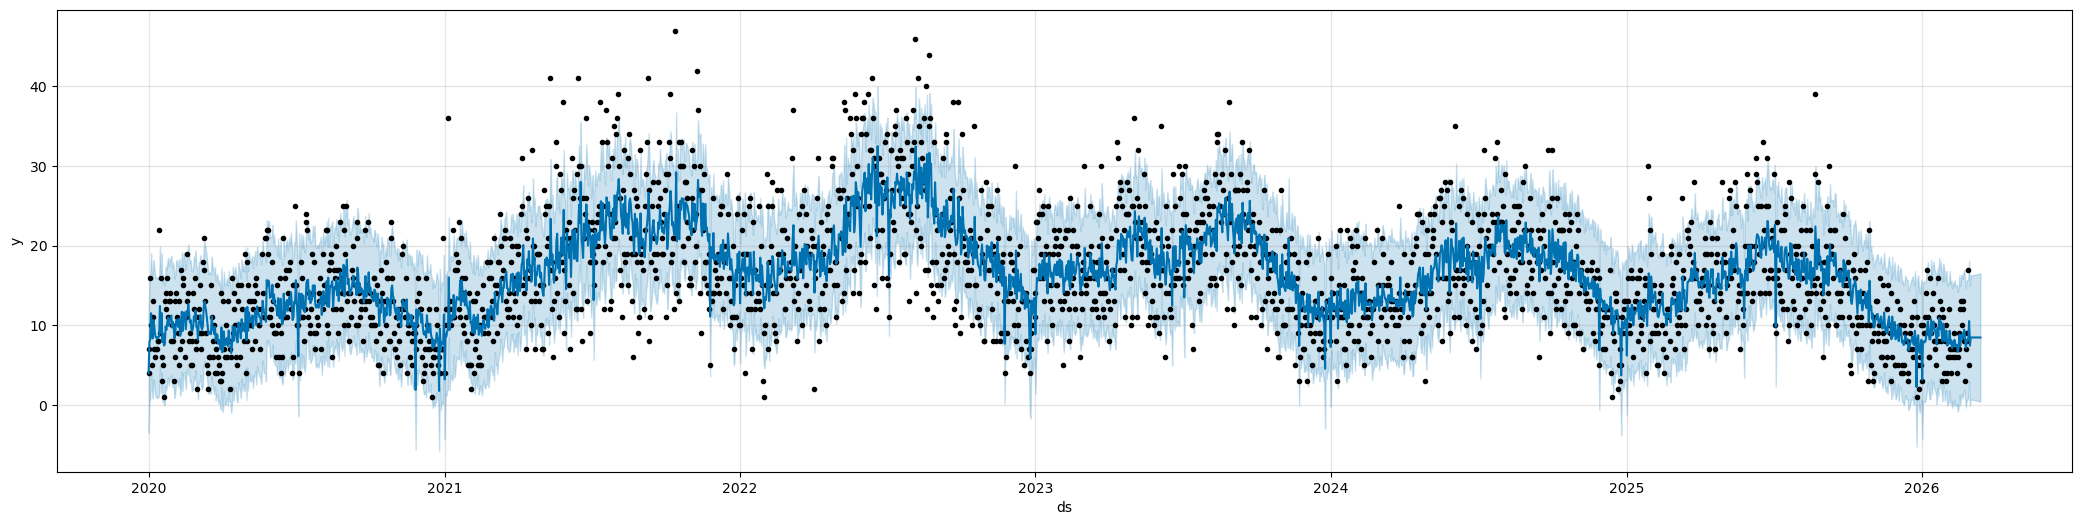

In [35]:
fig = plt.figure(figsize=(26, 6)) 
ax = fig.add_subplot(1, 1, 1)
m.plot(forecast, ax=ax)
plt.show()